In [10]:
import os
from dotenv import load_dotenv
from copy import deepcopy
load_dotenv()
os.chdir(os.getenv('PARENT_DIR'))

In [11]:
from glob import glob
import json
paths = glob('results/async/Qwen3-8B/hotel_reviews/indo/mvp_aos/exp1/max_retries_*/seed_42/*/inference_results.json')
paths

['results/async/Qwen3-8B/hotel_reviews/indo/mvp_aos/exp1/max_retries_3/seed_42/2026-03-01_21-24-43/inference_results.json',
 'results/async/Qwen3-8B/hotel_reviews/indo/mvp_aos/exp1/max_retries_5/seed_42/2026-03-01_23-17-32/inference_results.json',
 'results/async/Qwen3-8B/hotel_reviews/indo/mvp_aos/exp1/max_retries_10/seed_42/2026-03-02_01-21-36/inference_results.json',
 'results/async/Qwen3-8B/hotel_reviews/indo/mvp_aos/exp1/max_retries_1/seed_42/2026-03-01_19-49-25/inference_results.json']

In [24]:
costs = {
    # 'deepseek v3.2': {
    #     'input': 0.252 * 10**-6,
    #     'output': 0.468 * 10**-6
	# },
    'Gemini Pro 3.1 Preview': {
        'input': 0.738 * 10**-6,
		'output': 12.19 * 10**-6
	},
    'GLM-5': {
        'input': 0.560 * 10**-6,
		'output': 3.10 * 10**-6
	},
    'Gemini Flash 3 Preview': {
        'input': 0.308 * 10**-6,
		'output': 3.00 * 10**-6
	},
    'GPT-5.2': {
        'input': 1.17 * 10**-6,
		'output': 14.00 * 10**-6
	},
    'Kimi K2.5': {
        'input': 0.246 * 10**-6,
        'output': 2.78 * 10**-6
	},
	'Claude Sonnet 4.6': {
        'input': 1.65 * 10**-6,
        'output': 15.11 * 10**-6
	},
	'Claude Opus 4.6': {
        'input': 2.29 * 10**-6,
        'output': 25.32 * 10**-6
	}
}

In [25]:
data_raw = {
    'model': [],
    'input_cost_per_token': [],
    'output_cost_per_token': [],
	'max_retries': [],
    'input_cost_per_seed': [],
    'thinking_cost_per_seed': [],
	'output_cost_per_seed': [],
    'total_cost_per_seed': [],
    'input_cost': [],
    'thinking_cost': [],
	'output_cost': [],
    'total_cost': []
}

In [26]:
for path in paths:
	with open(path, 'r') as f:
		data = json.load(f)
	max_retries = path.split('/')[7].split('_')[-1]
	print(f'Max Retries: {max_retries}')
	total_thinking_tokens = sum([d['token_usage']['thinking_tokens'] for d in data])
	total_input_tokens = sum([d['token_usage']['input_tokens'] for d in data])
	total_output_tokens = sum([d['token_usage']['output_tokens'] for d in data])
	print(f'Total Thinking Tokens: {total_thinking_tokens}')
	print(f'Total Input Tokens: {total_input_tokens}')
	print(f'Total Output Tokens: {total_output_tokens}')
	# Print cost for each model
	for model, token_costs in costs.items():
		thinking_cost = total_thinking_tokens * token_costs['output']
		input_cost = total_input_tokens * token_costs['input']
		output_cost = total_output_tokens * token_costs['output']
		total_cost = thinking_cost + input_cost + output_cost
		print(f'{model} Cost per seed: ${total_cost:.6f}')
		print(f'  Thinking Cost per seeds: ${thinking_cost:.6f}')
		print(f'  Input Cost per seeds: ${input_cost:.6f}')
		print(f'  Output Cost per seeds: ${output_cost:.6f}')
		total_seeds = 5
		print(f'Total cost for all seeds: ${total_cost * total_seeds:.6f}')
		print('-------')
		data_raw['model'].append(model)
		data_raw['input_cost_per_token'].append(token_costs['input'])
		data_raw['output_cost_per_token'].append(token_costs['output'])
		data_raw['max_retries'].append(max_retries)
		data_raw['input_cost_per_seed'].append(input_cost)
		data_raw['thinking_cost_per_seed'].append(thinking_cost)
		data_raw['output_cost_per_seed'].append(output_cost)
		data_raw['total_cost_per_seed'].append(total_cost)
		data_raw['input_cost'].append(input_cost * total_seeds)
		data_raw['thinking_cost'].append(thinking_cost * total_seeds)
		data_raw['output_cost'].append(output_cost * total_seeds)
		data_raw['total_cost'].append(total_cost * total_seeds)

Max Retries: 3
Total Thinking Tokens: 2397623
Total Input Tokens: 1556283
Total Output Tokens: 262083
Gemini Pro 3.1 Preview Cost per seed: $33.570353
  Thinking Cost per seeds: $29.227024
  Input Cost per seeds: $1.148537
  Output Cost per seeds: $3.194792
Total cost for all seeds: $167.851765
-------
GLM-5 Cost per seed: $9.116607
  Thinking Cost per seeds: $7.432631
  Input Cost per seeds: $0.871518
  Output Cost per seeds: $0.812457
Total cost for all seeds: $45.583035
-------
Gemini Flash 3 Preview Cost per seed: $8.458453
  Thinking Cost per seeds: $7.192869
  Input Cost per seeds: $0.479335
  Output Cost per seeds: $0.786249
Total cost for all seeds: $42.292266
-------
GPT-5.2 Cost per seed: $39.056735
  Thinking Cost per seeds: $33.566722
  Input Cost per seeds: $1.820851
  Output Cost per seeds: $3.669162
Total cost for all seeds: $195.283676
-------
Kimi K2.5 Cost per seed: $7.776828
  Thinking Cost per seeds: $6.665392
  Input Cost per seeds: $0.382846
  Output Cost per seed

In [27]:
import pandas as pd
df_cost = pd.DataFrame(data_raw)
df_cost

,model,input_cost_per_token,output_cost_per_token,max_retries,input_cost_per_seed,thinking_cost_per_seed,output_cost_per_seed,total_cost_per_seed,input_cost,thinking_cost,output_cost,total_cost
0,Gemini Pro 3.1 Preview,7.380000e-07,0.000012,3,1.148537,29.227024,3.194792,33.570353,5.742684,146.135122,15.973959,167.851765
1,GLM-5,5.600000e-07,0.000003,3,0.871518,7.432631,0.812457,9.116607,4.357592,37.163156,4.062286,45.583035
2,Gemini Flash 3 Preview,3.080000e-07,0.000003,3,0.479335,7.192869,0.786249,8.458453,2.396676,35.964345,3.931245,42.292266
3,GPT-5.2,1.170000e-06,0.000014,3,1.820851,33.566722,3.669162,39.056735,9.104256,167.833610,18.345810,195.283676
4,Kimi K2.5,2.460000e-07,0.000003,3,0.382846,6.665392,0.728591,7.776828,1.914228,33.326960,3.642954,38.884141
5,Claude Sonnet 4.6,1.650000e-06,0.000015,3,2.567867,36.228084,3.960074,42.756025,12.839335,181.140418,19.800371,213.780123
6,Claude Opus 4.6,2.290000e-06,0.000025,3,3.563888,60.707814,6.635942,70.907644,17.819440,303.539072,33.179708,354.538220
7,Gemini Pro 3.1 Preview,7.380000e-07,0.000012,5,1.123457,28.274717,3.077573,32.475747,5.617287,141.373586,15.387864,162.378737
8,GLM-5,5.600000e-07,0.000003,5,0.852488,7.190453,0.782648,8.825589,4.262440,35.952266,3.913238,44.127944
9,Gemini Flash 3 Preview,3.080000e-07,0.000003,5,0.468868,6.958503,0.757401,8.184772,2.344342,34.792515,3.787005,40.923862


In [30]:
# Take only Claude Opus 4.6 and Claude Sonnet 4.6
df_cost = df_cost[df_cost['model'].isin(['Claude Opus 4.6', 'Claude Sonnet 4.6'])]

In [31]:
# Round all cost columns to 3 decimal places
cost_columns = ['input_cost_per_seed', 'thinking_cost_per_seed', 'output_cost_per_seed', 'total_cost_per_seed', 'input_cost', 'thinking_cost', 'output_cost', 'total_cost']
df_cost[cost_columns] = df_cost[cost_columns].round(3)


In [32]:
df_cost.to_csv('temp/cost.csv', index=False)

In [34]:
test_path = 'results/async/Qwen3-8B/hotel_reviews/indo/mvp_aos/exp1/max_retries_10/seed_42/2026-03-02_01-21-36/inference_results.json'
with open(test_path, 'r') as f:
	test_data = json.load(f)
test_data[0]['attempts']

1

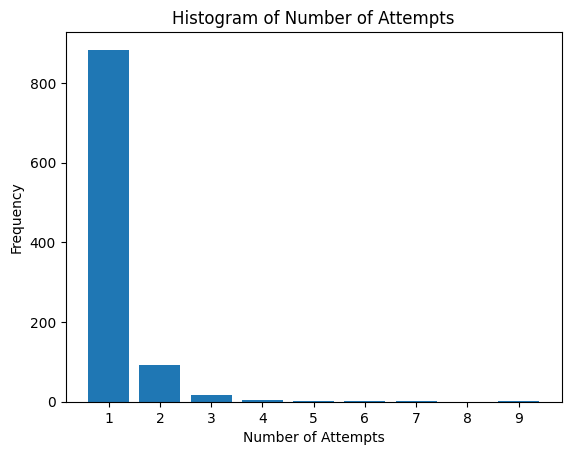

In [36]:
# Make histogram of number of attempts for test_data
import matplotlib.pyplot as plt
attempts = [d['attempts'] for d in test_data]
plt.hist(attempts, bins=range(1, max(attempts)+2), align='left', rwidth=0.8)
plt.xlabel('Number of Attempts')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Attempts')
plt.xticks(range(1, max(attempts)+1))
plt.show()

In [38]:
# Make freq table of number of attempts
from collections import Counter
attempt_counts = Counter(attempts)
print("Number of Attempts | Frequency")
for attempt, freq in attempt_counts.items():
	print(f"{attempt} | {freq}")

Number of Attempts | Frequency
1 | 883
2 | 91
4 | 5
3 | 16
5 | 1
6 | 2
9 | 1
7 | 1


In [42]:
df_count = pd.DataFrame.from_dict(attempt_counts, orient='index', columns=['frequency']).reset_index().rename(columns={'index': 'attempts'})
df_count.sort_values('attempts')

,attempts,frequency
0,1,883
1,2,91
3,3,16
2,4,5
4,5,1
5,6,2
7,7,1
6,9,1
